In [1]:
%pip install sklearn

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

In [2]:
# Step 0: Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Create a sample House Price Dataset for 100 homes to practice with
np.random.seed(42)
sizes = np.random.randint(500, 3500, 100) # Size in sq ft
# Base price + price per sqft + random noise
prices = 50000 + (sizes * 150) + np.random.normal(0, 20000, 100) 

df = pd.DataFrame({'Avg_Area_Income': np.random.randint(40000, 90000, 100),
                   'House_Size_SqFt': sizes,
                   'Rooms': np.random.randint(2, 6, 100),
                   'Price': prices})

print("--- Step 1: House Price Dataset Initialized ---")
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns.\n")
print(df.head())

--- Step 1: House Price Dataset Initialized ---
Dataset shape: 100 rows, 4 columns.

   Avg_Area_Income  House_Size_SqFt  Rooms          Price
0            42049             1360      4  265642.455894
1            71616             1794      5  336854.969192
2            78191             1630      3  312386.646602
3            87357             1595      5  304349.955945
4            60932             2138      3  366556.682198


In [3]:
# 1. Split data into training and testing sets.
# Features (X) and Target variable (y)
X = df[['House_Size_SqFt']] # Let's use House Size to predict Price
y = df['Price']

# Split: 80% Training data, 20% Testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("\n--- Step 2: Data Split Complete ---")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples\n")


--- Step 2: Data Split Complete ---
Training set size: 80 samples
Testing set size: 20 samples



In [4]:
# 2. Train the linear regression model.
model = LinearRegression()
model.fit(X_train, y_train) # Training the model
print("--- Step 3: Linear Regression Model Trained Successfully ---")
print(f"Model Coefficient (Slope): {model.coef_[0]:.2f}")
print(f"Model Intercept: {model.intercept_:.2f}\n")

--- Step 3: Linear Regression Model Trained Successfully ---
Model Coefficient (Slope): 149.17
Model Intercept: 52039.91



In [5]:
# 3. Predict values for the test set.
y_pred = model.predict(X_test)

# Create a report comparing Actual vs Predicted values
report_df = pd.DataFrame({'Actual Price': y_test, 'Predicted Price': y_pred})
report_df['Error'] = report_df['Actual Price'] - report_df['Predicted Price']
print("--- Step 4: Predictions Generated (First 5 Rows of Report) ---")
print(report_df.head())

# Save the predictions report to a CSV file as requested in deliverables
report_df.to_csv('predicted_values_report.csv', index=False)

--- Step 4: Predictions Generated (First 5 Rows of Report) ---
     Actual Price  Predicted Price         Error
83  493921.788313    476135.705481  17786.082832
53  508153.701336    547887.403424 -39733.702088
70  245645.936774    231344.569671  14301.367103
45  451260.946583    456892.526615  -5631.580031
44  583674.672403    557434.406893  26240.265510


In [6]:
# 4. Evaluate model performance using RMSE.
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Root Mean Squared Error
print("\n--- Step 5: Model Evaluation ---")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}\n")


--- Step 5: Model Evaluation ---
Root Mean Squared Error (RMSE): $19103.88



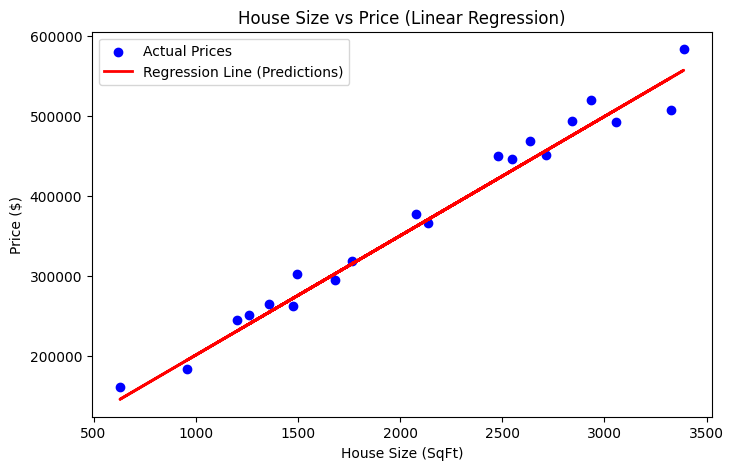

In [7]:
# Optional Visual: Plotting the Regression Line
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color='blue', label='Actual Prices')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line (Predictions)')
plt.title('House Size vs Price (Linear Regression)')
plt.xlabel('House Size (SqFt)')
plt.ylabel('Price ($)')
plt.legend()
plt.show()